In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

cwd = Path.cwd()
PROJECT_ROOT = find_project_root(cwd)
print("CWD         :", cwd)
print("PROJECT_ROOT:", PROJECT_ROOT)

ANALYSIS_SUBDIR = "newAnalysis"   # change to "analysis" if needed
analysis_dir = PROJECT_ROOT / ANALYSIS_SUBDIR
print("Analysis dir:", analysis_dir)

CWD         : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks
PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
Analysis dir: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/newAnalysis


In [10]:
DOMAINCNN_TAGS = [
    "domain_cnn_baseline",
    "domain_cnn_A1_geo",
    "domain_cnn_A2_photo",
    "domain_cnn_A3_norm",
    "domain_cnn_A4_realistic",
    "domain_cnn_A5_noisy",
]

def load_tsne_df(tag: str) -> pd.DataFrame:
    path = analysis_dir / f"{tag}_tsne.csv"
    df = pd.read_csv(path)
    print(f"[{tag}] t-SNE df shape:", df.shape)
    return df

def load_test_results_df(tag: str) -> pd.DataFrame:
    path = analysis_dir / f"{tag}_test_results.csv"
    df = pd.read_csv(path)
    print(f"[{tag}] test_results df shape:", df.shape)
    return df

In [11]:
TAG = "domain_cnn_baseline"  # change to any tag you want

try:
    tsne_df = load_tsne_df(TAG)

    iam_mask = (tsne_df["true_label"].to_numpy() == 0)
    emu_mask = (tsne_df["true_label"].to_numpy() == 1)
    mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

    plt.figure(figsize=(7, 6))

    plt.scatter(tsne_df.loc[iam_mask, "tsne_x"], tsne_df.loc[iam_mask, "tsne_y"],
                s=6, alpha=0.4, label="IAM (genuine)")
    plt.scatter(tsne_df.loc[emu_mask, "tsne_x"], tsne_df.loc[emu_mask, "tsne_y"],
                s=6, alpha=0.4, label="Emuru (fake)")

    if mis_mask.any():
        plt.scatter(tsne_df.loc[mis_mask, "tsne_x"], tsne_df.loc[mis_mask, "tsne_y"],
                    s=40, edgecolors="k", facecolors="none", linewidths=1.0,
                    label="Misclassified")

    plt.title(f"DomainCNN t-SNE ({TAG})")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"[{TAG}] Missing {analysis_dir / f'{TAG}_tsne.csv'} (run analysis with --tsne to generate it).")

[domain_cnn_baseline] Missing /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/newAnalysis/domain_cnn_baseline_tsne.csv (run analysis with --tsne to generate it).


[domain_cnn_A4_realistic] t-SNE df shape: (800, 8)


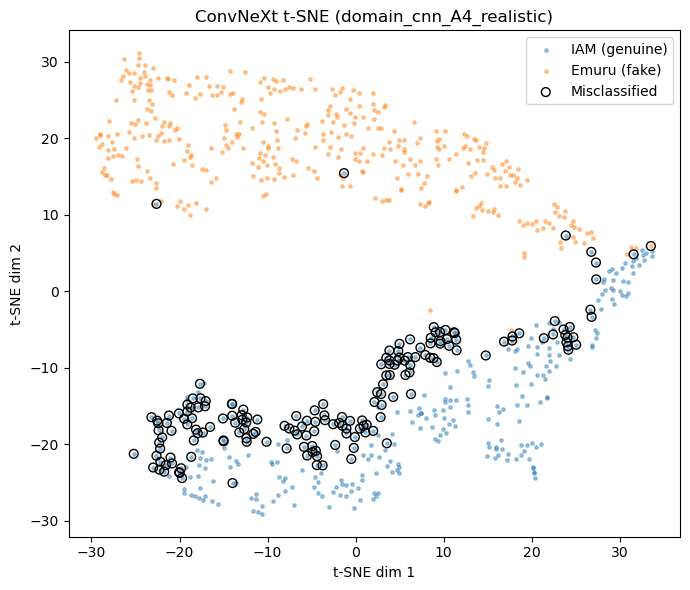

In [12]:
TAG = "domain_cnn_A4_realistic"   # change

if (analysis_dir / f"{TAG}_tsne.csv").exists():
    tsne_df = load_tsne_df(TAG)

    iam_mask = (tsne_df["true_label"].to_numpy() == 0)
    emu_mask = (tsne_df["true_label"].to_numpy() == 1)
    mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

    plt.figure(figsize=(7, 6))
    plt.scatter(tsne_df.loc[iam_mask, "tsne_x"], tsne_df.loc[iam_mask, "tsne_y"],
                s=6, alpha=0.4, label="IAM (genuine)")
    plt.scatter(tsne_df.loc[emu_mask, "tsne_x"], tsne_df.loc[emu_mask, "tsne_y"],
                s=6, alpha=0.4, label="Emuru (fake)")

    if mis_mask.any():
        plt.scatter(tsne_df.loc[mis_mask, "tsne_x"], tsne_df.loc[mis_mask, "tsne_y"],
                    s=40, edgecolors="k", facecolors="none", linewidths=1.0,
                    label="Misclassified")

    plt.title(f"ConvNeXt t-SNE ({TAG})")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Missing:", analysis_dir / f"{TAG}_tsne.csv")

[domain_cnn_baseline] missing tsne csv, skipping grid panel.
[domain_cnn_A5_noisy] missing tsne csv, skipping grid panel.
[domain_cnn_A4_realistic] t-SNE df shape: (800, 8)


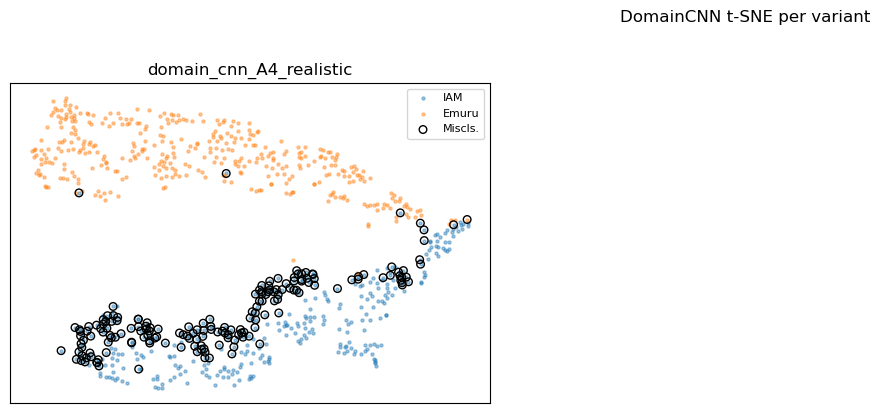

In [14]:
TAGS_FOR_GRID = [
    "domain_cnn_baseline",
    "domain_cnn_A4_realistic",
    "domain_cnn_A5_noisy",
]

available = []
for tag in TAGS_FOR_GRID:
    if (analysis_dir / f"{tag}_tsne.csv").exists():
        available.append(tag)
    else:
        print(f"[{tag}] missing tsne csv, skipping grid panel.")

if available:
    n = len(available)
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, tag in enumerate(available, start=1):
        tsne_df = load_tsne_df(tag)
        iam_mask = (tsne_df["true_label"].to_numpy() == 0)
        emu_mask = (tsne_df["true_label"].to_numpy() == 1)
        mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

        ax = plt.subplot(rows, cols, i)
        ax.scatter(tsne_df.loc[iam_mask, "tsne_x"], tsne_df.loc[iam_mask, "tsne_y"],
                   s=5, alpha=0.4, label="IAM")
        ax.scatter(tsne_df.loc[emu_mask, "tsne_x"], tsne_df.loc[emu_mask, "tsne_y"],
                   s=5, alpha=0.4, label="Emuru")

        if mis_mask.any():
            ax.scatter(tsne_df.loc[mis_mask, "tsne_x"], tsne_df.loc[mis_mask, "tsne_y"],
                       s=30, edgecolors="k", facecolors="none", linewidths=1.0,
                       label="Miscls.")

        ax.set_title(tag)
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 1:
            ax.legend(fontsize=8)

    plt.suptitle("DomainCNN t-SNE per variant", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No t-SNE CSVs found for the selected tags.")

In [16]:
acc_rows = []

for tag in DOMAINCNN_TAGS:
    path = analysis_dir / f"{tag}_test_results.csv"
    if not path.exists():
        print(f"[{tag}] test_results CSV not found, skipping.")
        continue

    df_res = pd.read_csv(path)
    acc = (df_res["true_label"] == df_res["pred_label"]).mean()
    acc_rows.append({"tag": tag, "accuracy": acc})

acc_df = pd.DataFrame(acc_rows).sort_values("tag")
acc_df

,tag,accuracy
1,domain_cnn_A1_geo,0.968761
2,domain_cnn_A2_photo,0.985652
3,domain_cnn_A3_norm,0.648565
4,domain_cnn_A4_realistic,0.792227
5,domain_cnn_A5_noisy,0.993643
0,domain_cnn_baseline,0.998184


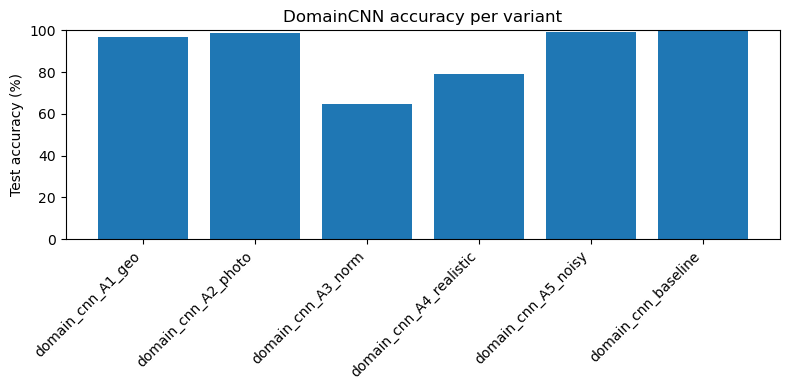

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(acc_df["tag"], acc_df["accuracy"] * 100.0)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("DomainCNN accuracy per variant")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [9]:
rows = []

for tag in DOMAINCNN_TAGS:
    path = analysis_dir / f"{tag}_test_results.csv"
    if not path.exists():
        continue

    df_res = pd.read_csv(path)
    y_true = df_res["true_label"].to_numpy()
    y_pred = df_res["pred_label"].to_numpy()

    mask_iam = (y_true == 0)
    mask_emu = (y_true == 1)

    acc_iam = (y_pred[mask_iam] == 0).mean() if mask_iam.any() else np.nan
    acc_emu = (y_pred[mask_emu] == 1).mean() if mask_emu.any() else np.nan

    rows.append({"tag": tag, "acc_iam": acc_iam, "acc_emuru": acc_emu})

per_class_df = pd.DataFrame(rows).sort_values("tag")
per_class_df

,tag,acc_iam,acc_emuru
1,domain_cnn_A1_geo,1.000000,0.937523
2,domain_cnn_A2_photo,0.994551,0.976753
3,domain_cnn_A3_norm,1.000000,0.297130
4,domain_cnn_A4_realistic,0.588449,0.996004
5,domain_cnn_A5_noisy,0.988013,0.999274
0,domain_cnn_baseline,1.000000,0.996368


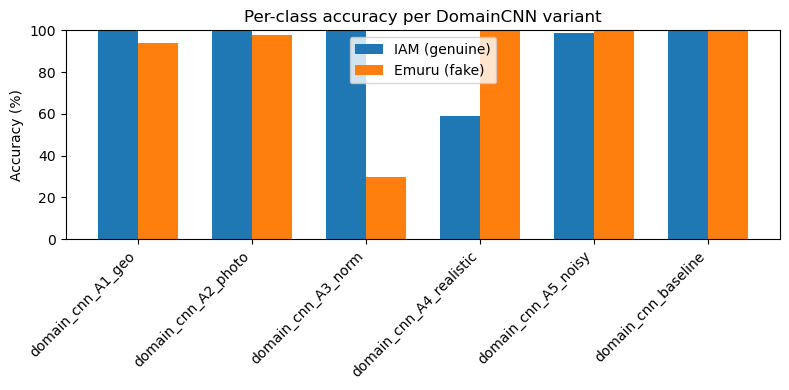

In [10]:
x = np.arange(len(per_class_df))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, per_class_df["acc_iam"] * 100.0, width, label="IAM (genuine)")
plt.bar(x + width/2, per_class_df["acc_emuru"] * 100.0, width, label="Emuru (fake)")

plt.xticks(x, per_class_df["tag"], rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Per-class accuracy per DomainCNN variant")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

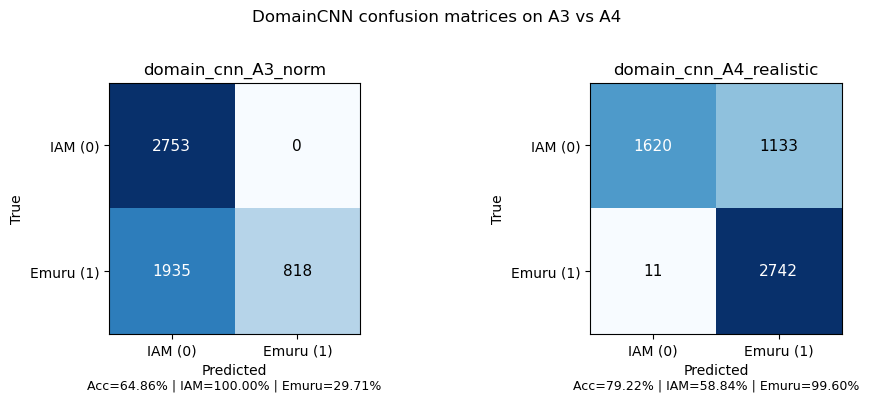

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def confusion_matrix_from_df(df: pd.DataFrame) -> np.ndarray:
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(df["true_label"].to_numpy(), df["pred_label"].to_numpy()):
        cm[int(t), int(p)] += 1
    return cm

def add_cm_to_ax(ax, cm: np.ndarray, title: str, cmap="Blues"):
    ax.imshow(cm, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["IAM (0)", "Emuru (1)"])
    ax.set_yticklabels(["IAM (0)", "Emuru (1)"])

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.0
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=11)

    acc_iam = cm[0, 0] / cm[0].sum() if cm[0].sum() else 0.0
    acc_emu = cm[1, 1] / cm[1].sum() if cm[1].sum() else 0.0
    overall = (cm[0,0] + cm[1,1]) / cm.sum() if cm.sum() else 0.0

    ax.text(
        0.5, -0.18,
        f"Acc={overall*100:.2f}% | IAM={acc_iam*100:.2f}% | Emuru={acc_emu*100:.2f}%",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

TAGS = ["domain_cnn_A3_norm", "domain_cnn_A4_realistic"]

cms, titles = [], []
for tag in TAGS:
    path = analysis_dir / f"{tag}_test_results.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    df_res = pd.read_csv(path)
    cms.append(confusion_matrix_from_df(df_res))
    titles.append(tag)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes, cms, titles):
    add_cm_to_ax(ax, cm, title, cmap="Blues")

plt.suptitle("DomainCNN confusion matrices on A3 vs A4", y=1.02)
plt.tight_layout()
plt.show()
